# Actividad 7 — Tipologías de comunas y regiones socioeconómicas en la RM



## Contexto

En la clase aplicamos a San Diego las técnicas de clustering y regionalización vistas en `07_regionalizacion.ipynb` (cap. 10 de *Geographic Data Science with Python*). Hoy las usamos sobre las **52 comunas de la Región Metropolitana**.

La pregunta es doble:

1. **Sin restricción espacial**: ¿en cuántos *tipos* distintos de comunas se divide la RM si miramos su perfil socioeconómico (ingreso, educación, demografía)?
2. **Con restricción espacial**: si exigimos que cada grupo sea una *región contigua*, ¿cómo cambian los grupos? ¿Las divisiones administrativas existentes (las 6 provincias) se parecen a las regiones que emergen de los datos?

## Datos

El archivo `datos/external/casen_rm/rm_socioeconomico.gpkg` (generado por el preámbulo) tiene 52 comunas con:

- **CASEN 2017:** `ypc_aut_2017`, `ypc_tot_2017`, `pct_ganancia_transf`
- **Censo 2017:** `escolaridad_prom`, `pct_educ_superior`, `tasa_empleo`, `edad_promedio`, `pct_adulto_mayor`, `pct_menor`, `pct_migrante`, `pct_indigena`, `razon_dependencia`, `poblacion_total`
- `nom_prov` para las 6 provincias administrativas (Santiago, Cordillera, Maipo, Chacabuco, Talagante, Melipilla)

## Reglas

- Suban este notebook con sus respuestas (código + texto en markdown) ejecutado.
- Las preguntas marcadas **Interpretación** se responden en celdas markdown — no basta con código.
- No es necesario ejecutar el preámbulo: el archivo `.gpkg` ya está disponible.

## 0. Setup

In [66]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import robust_scale
from sklearn.cluster import KMeans, AgglomerativeClustering
from libpysal.weights import Queen, KNN
from esda.moran import Moran
from scipy.sparse.csgraph import connected_components

warnings.filterwarnings("ignore")
sns.set_context("notebook")
np.random.seed(42)

gdf = gpd.read_file("rm_socioeconomico.gpkg")
print(f"{len(gdf)} comunas RM cargadas | CRS: {gdf.crs}")
gdf.head(3)

52 comunas RM cargadas | CRS: EPSG:32719


,cod_comuna,nom_comuna,nom_prov,ypc_aut_2017,ypc_tot_2017,pct_ganancia_transf,escolaridad_prom,pct_educ_superior,tasa_empleo,edad_promedio,pct_adulto_mayor,pct_menor,razon_dependencia,pct_migrante,pct_indigena,poblacion_total,geometry
0,13404,PAINE,MAIPO,285365.876995,353275.520186,23.797394,10.139286,16.309352,56.632357,34.498619,9.736253,21.885952,0.462463,2.318614,8.547396,72759,"POLYGON ((350033.92 6265707.472, 350106.705 62..."
1,13402,BUIN,MAIPO,215822.686195,272555.328224,26.286691,10.888701,22.457746,58.878866,33.673950,8.749250,22.431532,0.453082,1.439750,8.144782,96614,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13124,PUDAHUEL,SANTIAGO,235630.811008,297166.493830,26.115296,11.034397,19.780937,60.356140,34.360958,8.483975,20.845184,0.415011,2.185911,12.287825,230293,"POLYGON ((333540.425 6307203.281, 333624.972 6..."


---

## Ejercicio 1 — Definición de variables y exploración

### 1.A — Selección de variables

Trabajaremos con un conjunto de **8 variables** que describen el perfil socioeconómico de cada comuna. Defínanlas en una lista llamada `cluster_variables`:

- `ypc_aut_2017` (ingreso)
- `pct_ganancia_transf` (impacto del Estado)
- `escolaridad_prom` (educación)
- `pct_educ_superior` (educación)
- `tasa_empleo` (empleo)
- `pct_adulto_mayor` (demografía)
- `pct_migrante` (demografía)
- `razon_dependencia` (demografía)

In [67]:
# Tu código aquí
cluster_variables = [
    'ypc_aut_2017', 'pct_ganancia_transf', 
    'escolaridad_prom', 'pct_educ_superior',
    'tasa_empleo', 'pct_adulto_mayor',
    'razon_dependencia', 'pct_migrante'
    ]

### 1.B — Mapas de las variables

Hagan una grilla de 2×4 con un mapa de cuantiles ($k=5$) de cada variable. Usen `cmap="viridis"` y oculten ejes.

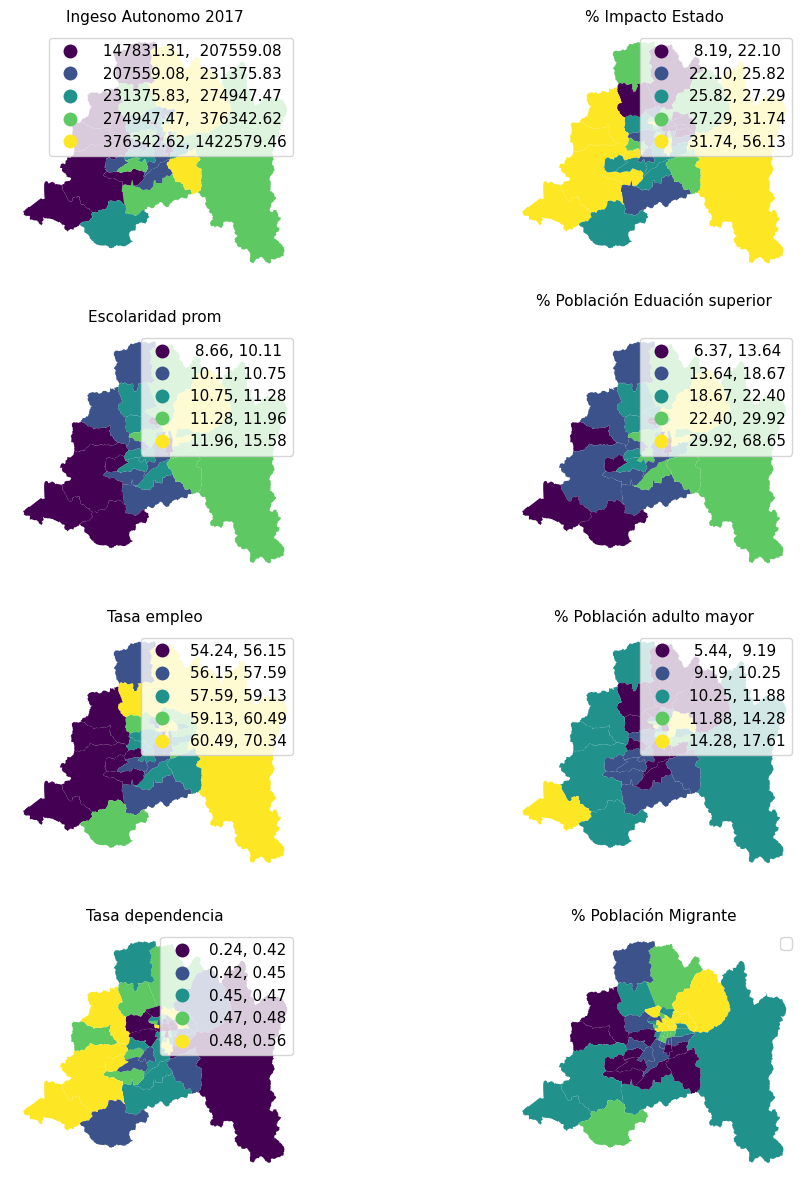

In [78]:
# Tu código aquí
titulos = {
    'ypc_aut_2017': 'Ingeso Autonomo 2017', 
    'pct_ganancia_transf': "% Impacto Estado", 
    'escolaridad_prom': "Escolaridad prom",
    'pct_educ_superior': "% Población Eduación superior",
    'tasa_empleo': "Tasa empleo",
    'pct_adulto_mayor': "% Población adulto mayor",
    'razon_dependencia': "Tasa dependencia",
    'pct_migrante': "% Población Migrante"
}
fig, axs = plt.subplots(4, 2, figsize=(12,12))
for ax, var in zip(axs.flatten(), cluster_variables):
    gdf.plot(
        column=var, scheme="Quantiles", k=5,
        cmap="viridis", linewidth=0, ax=ax, legend=True
    )
    ax.set_axis_off()
    ax.set_title(titulos[var], fontsize=11)
plt.legend(loc='best') 
plt.tight_layout()
plt.show()

### 1.C — Autocorrelación espacial

Construyan una matriz de pesos Queen (estandarizada por filas, `w.transform = "r"`) y calculen el **Moran's I** y su p-valor para cada variable. Reporten los resultados en un DataFrame ordenado por Moran's I descendente.



In [69]:
# Tu código aquí
w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"

moran_p = []
moran_i = []

for v in cluster_variables:
    mo = Moran(gdf[v], w)
    moran_i.append(mo.I)
    moran_p.append(mo.p_sim)

moran_resumen = pd.DataFrame(
    {"Moran I": moran_i, "p-valor": moran_p},
    index=cluster_variables,
)
moran_resumen.sort_values(by = 'Moran I', ascending=False)

,Moran I,p-valor
pct_educ_superior,0.533164,0.001
ypc_aut_2017,0.527309,0.001
escolaridad_prom,0.523376,0.001
pct_migrante,0.416980,0.001
pct_adulto_mayor,0.352809,0.001
pct_ganancia_transf,0.324042,0.001
tasa_empleo,0.320218,0.001
razon_dependencia,0.107326,0.059


### 1.D — Interpretación

1. ¿Cuáles variables muestran la autocorrelación espacial más fuerte? ¿Hay alguna que parezca distribuida casi al azar en el mapa?
2. ¿Tiene sentido aplicar regionalización a estos datos? ¿Por qué?

**Respuesta 1.D:** *(escriban acá)*

1. Variables como % eduación superior, ingreso autónomo y escolaridad promedio son las variables que tienen una autocorrelación espacial más fuerte. La variable de razón dependencia es la que tienen un indice de morán más bajo lo que se demuestra en el mapa al mostrarse casi al azar.

2. Si tiene sentido aplicar regionalización a los datos ya que tienen un indice de morán alto lo cual indica una relación espacial

---

## Ejercicio 2 — Clustering no espacial: K-Means

### 2.A — Estandarización + K-Means con k=5

1. Apliquen `robust_scale` a las 8 variables.
2. Ajusten un `KMeans(n_clusters=5, random_state=42, n_init=10)` sobre las variables escaladas.
3. Guarden las etiquetas como una nueva columna `gdf["k5"]` y reporten cuántas comunas hay en cada cluster.

In [70]:
# Tu código aquí
gdf_scaled = robust_scale(gdf[cluster_variables])
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(gdf_scaled)
gdf["k5"] = kmeans.labels_
gdf["k5"].value_counts().sort_index()

k5
0    23
1     3
2     2
3    21
4     3
Name: count, dtype: int64

### 2.B — Mapa de los clusters

Hagan un mapa categórico con los 5 clusters.

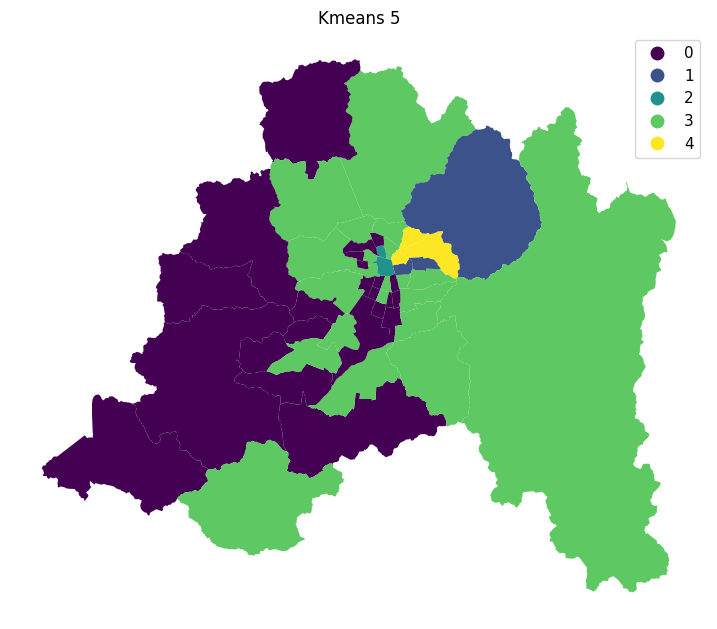

In [71]:
# Tu código aquí
fig, ax = plt.subplots(figsize = (9,9))
gdf.plot(column="k5", categorical=True, legend=True, cmap="viridis", linewidth=0, ax=ax)
ax.set_axis_off()
ax.set_title("Kmeans 5")
plt.show()

### 2.C — Perfiles por cluster

Construyan una tabla `perfil_k5` con el promedio de cada variable por cluster. 

In [72]:
# Tu código aquí
perfil_k5 = gdf.groupby("k5")[cluster_variables].mean().round(2)
perfil_k5

,ypc_aut_2017,pct_ganancia_transf,escolaridad_prom,pct_educ_superior,tasa_empleo,pct_adulto_mayor,razon_dependencia,pct_migrante
k5,,,,,,,,
0,208094.59,32.17,10.14,14.14,56.19,11.67,0.48,2.37
1,745802.57,20.74,14.27,55.79,61.30,12.36,0.45,4.83
2,415364.86,8.85,12.87,37.37,67.77,9.20,0.31,20.22
3,297415.17,25.32,11.42,25.27,59.95,10.22,0.44,3.62
4,1245079.83,18.39,15.41,67.44,61.63,16.29,0.47,7.52


### 2.D — Interpretación

1. **Etiqueten cada cluster** con un nombre que describa su perfil (ej. "comunas acomodadas", "periferia rural", "comunas céntricas con población migrante", etc.). Justifiquen brevemente con los valores de la tabla.
2. ¿Aparecen comunas del **mismo cluster en zonas geográficamente lejanas**? Den un ejemplo concreto. ¿Tendría sentido tratarlas como una misma "región" para fines administrativos?

**Respuesta 2.D:** *(escriban acá)*

Número cluster | Nombre
- 0 | 
- 1 | Comunas acomodadas
- 2 | Comunas con población migrante
- 3 | 
- 4 | 

---

## Ejercicio 3 — Regionalización: AHC con restricción espacial

### 3.A — AHC + Queen

Apliquen `AgglomerativeClustering` con `linkage="ward"`, `n_clusters=5` y `connectivity=w.sparse` (la matriz Queen del Ejercicio 1). Guarden las etiquetas en `gdf["reg_queen"]` y hagan el mapa correspondiente.

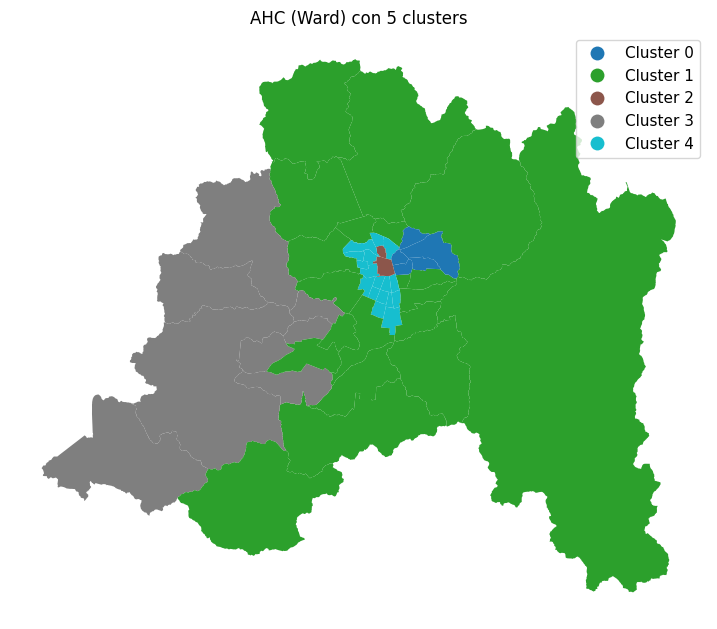

In [73]:
# Tu código aquí
ahc = AgglomerativeClustering(linkage="ward", n_clusters=5, connectivity=w.sparse)
ahc.fit(gdf_scaled)
gdf["reg_queen"] = ahc.labels_

fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(column="reg_queen", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("AHC (Ward) con 5 clusters")
plt.show()

### 3.B — AHC + KNN (k=4)

Repitan el ejercicio con una matriz `KNN.from_dataframe(gdf, k=4)`. Guarden las etiquetas como `gdf["reg_knn"]` y hagan el mapa.




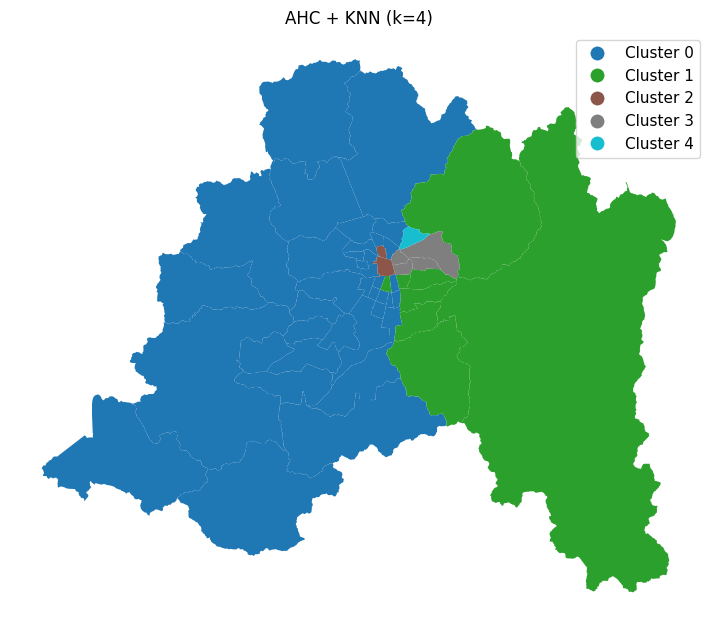

In [74]:
# Tu código aquí
w_knn = KNN.from_dataframe(gdf, k=4)
ahc_knn = AgglomerativeClustering(
    linkage="ward",
    n_clusters=5,
    connectivity=w_knn.sparse,
)
ahc_knn.fit(gdf_scaled)
gdf["reg_knn"] = ahc_knn.labels_

fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(column="reg_knn", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("AHC + KNN (k=4)")
plt.show()

### 3.C — Comparación visual

Pongan los tres mapas en una grilla 1×3: K-Means, Reg. Queen, Reg. KNN.

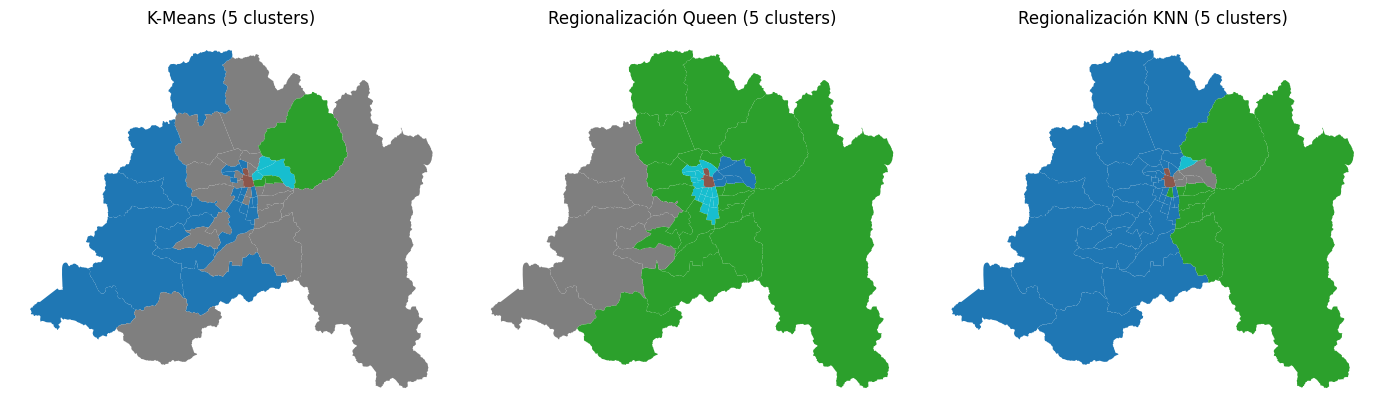

In [75]:
# Tu código aquí
fig, axs = plt.subplots(1, 3, figsize=(14, 14))
for ax, col, titulo in zip(
    axs.flatten(),
    ["k5", "reg_queen", "reg_knn"],
    ["K-Means", "Regionalización Queen", "Regionalización KNN"],
):
    n = gdf[col].nunique()
    gdf.plot(column=col, categorical=True, cmap="tab10", linewidth=0, ax=ax)
    ax.set_axis_off()
    ax.set_title(f"{titulo} ({n} clusters)")
plt.tight_layout()
plt.show()

### 3.D — Interpretación

1. ¿Qué grupos del K-Means "sobreviven" a la restricción espacial? ¿Cuáles se rompen?
2. ¿Cambia mucho el resultado entre Queen y KNN? Den un ejemplo de una comuna que cambia de grupo entre ambos.

**Respuesta 3.D:** *(escriban acá)*

---

## Ejercicio 4 — Métricas: trade-off entre atributos y geografía

### 4.A — WCSS y número de componentes conexos

Construyan una tabla `resultados` con índice `["K-Means", "Reg. Queen", "Reg. KNN", "Provincias"]` y dos columnas:

- `WCSS`: suma de cuadrados intra-cluster sobre las variables **escaladas**.
- `n_componentes`: suma del nº de componentes conexos por cluster, según la matriz **Queen**.

Para la fila `"Provincias"`, usen `gdf["nom_prov"]` como etiqueta de grupo (las 6 provincias administrativas).



In [76]:
# Tu código aquí
def wcss(etiquetas, X):
    total = 0.0
    for c in np.unique(etiquetas):
        Xc = X[etiquetas == c]
        total += ((Xc - Xc.mean(axis=0)) ** 2).sum()
    return total

def n_componentes(etiquetas, w):
    """Para cada cluster, cuenta cuántas piezas inconexas tiene en el mapa."""
    from scipy.sparse.csgraph import connected_components
    total = 0
    for c in np.unique(etiquetas):
        idx = np.where(etiquetas == c)[0]
        sub = w.sparse[idx][:, idx]
        n_comp, _ = connected_components(sub, directed=False)
        total += n_comp
    return total

resultados = pd.DataFrame(index=["K-Means", "Reg. Queen", "Reg. KNN", "Provincias"])
resultados["WCSS"] = [
    wcss(gdf["k5"].values,        gdf_scaled),
    wcss(gdf["reg_queen"].values, gdf_scaled),
    wcss(gdf["reg_knn"].values,   gdf_scaled),
    wcss(gdf["nom_prov"].values,      gdf_scaled),
]

resultados["# componentes"] = [
    n_componentes(gdf["k5"].values,        w),
    n_componentes(gdf["reg_queen"].values, w),
    n_componentes(gdf["reg_knn"].values,   w),
    n_componentes(gdf["nom_prov"].values,      w),
]
resultados


,WCSS,# componentes
K-Means,157.974507,11
Reg. Queen,195.631375,5
Reg. KNN,193.596589,6
Provincias,675.061272,6


### 4.B — Interpretación

1. ¿Quién gana en homogeneidad de atributos (WCSS)? ¿Quién en coherencia geográfica (componentes)?
2. Las 6 **provincias administrativas** existentes, ¿son una buena agrupación socioeconómica? Comparen su WCSS con la del K-Means y con la del AHC+Queen. ¿Conviene rediseñar las provincias en función del perfil socioeconómico, o las actuales son razonables?


**Respuesta 4.B:** *(escriban acá)*

En WCSS gana K-Means y en # componentes gana Reg. Queen.

Es notable que las provincias existentes no representan el perfil socioeconómico si miramos el WCSS. Creo que no es conveniente rediseñar las provincias en base al perfil socioeconómico ya que es una representación a un nivel muy alto para generar politicas de estado que sirvan para todos.